In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import itertools

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

In [2]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

In [3]:
from true_graph import TrueGraph
from learner import FactorGraphLearner, learner_to_graph
from noise_generator import IndependentMarginals
from metrics import *
from random_graph import generate_random_graph, generate_random_tree
from chow_liu import chow_liu

# Trees (Varying Graph Size)

In [4]:
TREE_SIZES = np.arange(5,51,5, dtype=np.int32)

In [5]:
tree_list = []
sample_list = []

for n in tqdm(TREE_SIZES):
    rng = np.random.default_rng(seed=165)
    g = generate_random_tree(n, 2, rng)
    samps = g.sample(500, seed=650, progress=False)
    tree_list.append(g)
    sample_list.append(samps)

100%|███████████████████████████████████████████| 10/10 [00:44<00:00,  4.42s/it]


# Graphs (Varying Graph Density)

In [6]:
N_VARIABLE = 12
NUM_FACTORS = list(range(4,13))

graph_list = []
graph_sample_list = []

for nf in tqdm(NUM_FACTORS):
    rng = np.random.default_rng(seed=882)
    g = generate_random_graph(N_VARIABLE, 2, rng, n_factors=nf)
    samps = g.sample(500, seed=648, progress=False)
    graph_list.append(g)
    graph_sample_list.append(samps)

100%|█████████████████████████████████████████████| 9/9 [00:17<00:00,  1.93s/it]


# Sample Sizes (Varying Sample Size)

(<Figure size 800x600 with 1 Axes>, <Axes: title={'center': 'Factor Graph'}>)

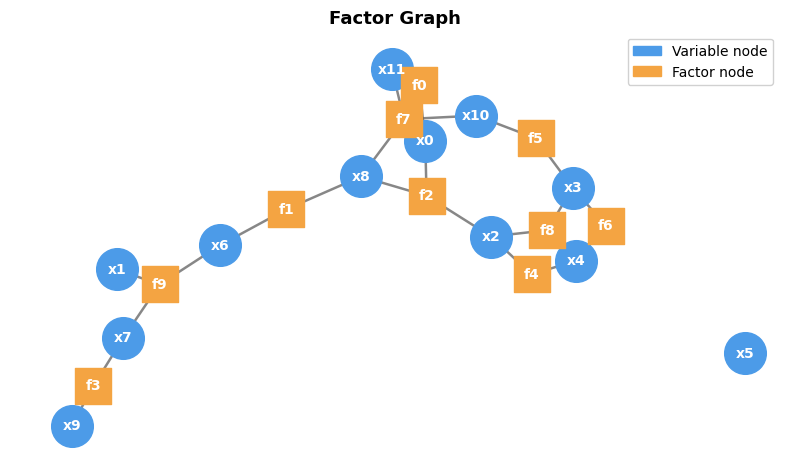

In [7]:
rng = np.random.default_rng(seed=688)
ss_graph = generate_random_graph(n=12, alphabet_size=2, rng=rng, n_factors=10)
ss_graph.display_graph(seed=1)

In [8]:
samples_list = []

all_samples = ss_graph.sample(10000, seed=390, progress=True)
for nsamp in [100,200,500,1000,2000,5000,10000]:
    samps = all_samples[:nsamp]
    samples_list.append(samps)

100%|████████████████████████████████████| 10000/10000 [00:33<00:00, 294.23it/s]


In [9]:
s_graph_list = [ss_graph for _ in samples_list]

# Learn

In [52]:
def run_learners(graph_list, sample_list, n_runs=5,
                 epochs=100, lr=0.01, seed=123,
                 lambda_bp=1e-3, lambda_mask=0.0, lambda_weight=0.0, lambda_mlp=1e-2, schedule=True):
    results = []
    lrn_seeds = np.random.default_rng(seed).integers(0,10000,size=n_runs)
    for i in tqdm(range(len(graph_list))):
        graph = graph_list[i]
        samples = sample_list[i]
        n_vars = graph.n
        log_lambda_here = (np.log10(lambda_bp) + 2.074) - 0.77 * np.log10(samples.shape[0])
        lambda_here = 10**log_lambda_here
        if n_vars <= 15:
            lambda_here = lambda_here
        elif n_vars >= 40:
            lambda_here = lambda_here * 5
        else:
            lambda_here = lambda_here * 2
        alph_size = graph.alphabet_sizes[0]
        n_factors = len(graph.factors)
        n_poss = alph_size**n_vars
        res = {x : [] for x in ["lrn", "KL", "SHD", "density"]}
        for j in range(n_runs):
            ng = IndependentMarginals(samples, alphabet_size=alph_size, alpha=1, seed=714)
            lrn = FactorGraphLearner(
                n_vars=n_vars,
                alphabet_size=alph_size,
                K=n_vars,
                noise_generator=ng,
                hidden_dims=(16,16),
                max_factor_size=5,
                shared_mlp=False,
                seed=lrn_seeds[j]
            )
            lrn.train(
                samples,
                n_epochs=epochs,
                lr=lr,
                lambda_mask=lambda_mask,
                lambda_weight=lambda_weight,
                lambda_mlp_l2=lambda_mlp,
                lambda_bp=lambda_here,
                penalty_schedule=schedule,
                verbose=False
            )
            res["lrn"].append(lrn)
            if n_poss <= 100000:
                res["KL"].append(kl_divergence(graph, lrn))
            res["SHD"].append(structural_hamming_distance(graph, lrn))
            res["density"].append(graph_density(lrn))
        chow_liu_res = chow_liu(samples, alph_size)
        results.append({
            'learners' : res["lrn"],
            'Chow-Liu Graph' : chow_liu_res,
            'True Graph' : graph,
            'n_samples' : samples.shape[0],
            'n_variables' : n_vars,
            'n_factors' : n_factors,
            'KL' : {'mean' : np.mean(res["KL"]), 'sd' : np.std(res["KL"])} if n_poss <= 100000 else {'mean' : None, 'sd' : None},
            'KL Chow-Liu' : kl_divergence(graph, chow_liu_res) if n_poss <= 100000 else None,
            'KL MLE' : kl_mle_optimal(graph, samples) if n_poss <= 100000 else None,
            'SHD' : {'mean' : np.mean(res["SHD"]), 'sd' : np.std(res["SHD"])},
            'SHD Chow-Liu' : structural_hamming_distance(graph, chow_liu_res),
            'true density' : graph_density(graph),
            'density' : {'mean' : np.mean(res["density"]), 'sd' : np.std(res["density"])}
        })
    return results

In [53]:
results_trees = run_learners(tree_list, sample_list, lambda_bp=1e-3)

100%|███████████████████████████████████████████| 10/10 [06:12<00:00, 37.21s/it]


In [16]:
results_graphs = run_learners(graph_list, graph_sample_list, lambda_bp=1e-3)

100%|█████████████████████████████████████████████| 9/9 [02:41<00:00, 17.98s/it]


In [17]:
results_samples = run_learners(s_graph_list, samples_list, lambda_bp=1e-3)

100%|█████████████████████████████████████████████| 7/7 [10:29<00:00, 89.93s/it]


# Visuals

In [18]:
def plot_results(results, x, y):
    xs = [r[x] for r in results]
    if isinstance(results[0][y], dict):
        ys = [r[y]['mean'] for r in results]
        yerr = [r[y]['sd'] for r in results]
        plt.errorbar(xs, ys, yerr=yerr, fmt='o', capsize=3)
    else:
        ys = [r[y] for r in results]
        plt.scatter(xs, ys)
        plt.plot(xs, ys)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

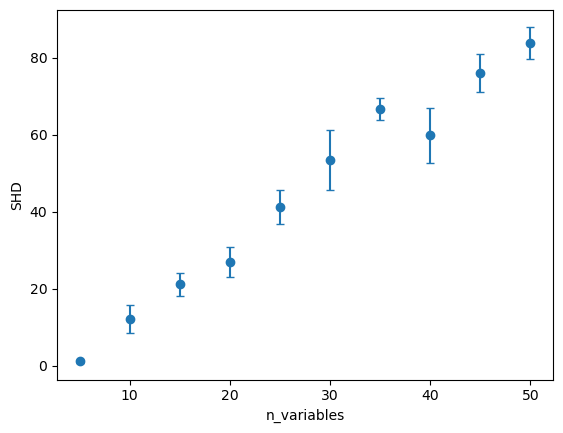

In [19]:
plot_results(results_trees, 'n_variables', 'SHD')

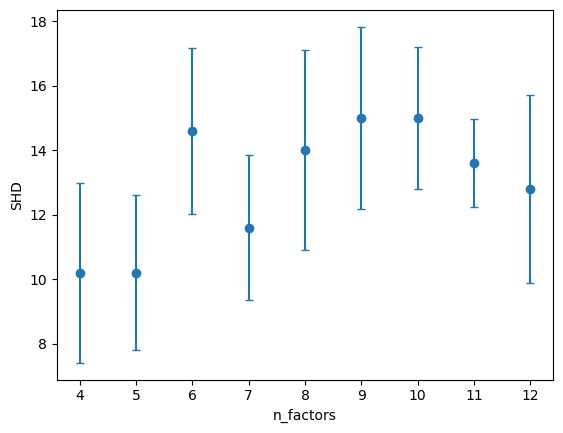

In [20]:
plot_results(results_graphs, 'n_factors', 'SHD')

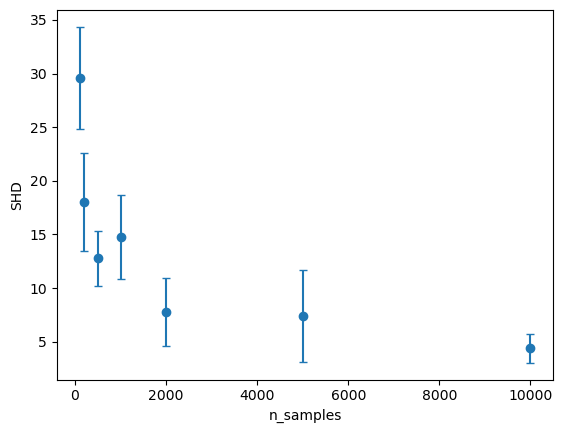

In [21]:
plot_results(results_samples, 'n_samples', 'SHD')

# Recovered Graphs

In [22]:
def learner_to_graph(lrn):
    fscopes = lrn.extract_graph()['factor_scopes']
    def h(): return 1
    factors = [(f, h) for f in fscopes.values()]
    g = TrueGraph(n=lrn.network.n_vars, factors=factors)
    return g

In [25]:
def show_graphs(result, index=0, seed_true=1, seed_lrn=1, seed_cl=1, size=6, savefig=False, path=""):
    true_graph = result['True Graph']
    lrn = result['learners'][index]
    cl = result['Chow-Liu Graph']
    
    fig, axs = plt.subplots(1,3, figsize=(3*size,size))

    true_graph.display_graph(seed=seed_true, ax=axs[0])
    learner_to_graph(lrn).display_graph(seed=seed_lrn, ax=axs[1])
    cl.display_graph(seed=seed_cl, ax=axs[2])
    
    axs[0].set_title("True Graph")
    axs[1].set_title("Network Learned Graph")
    axs[2].set_title("Chow-Liu Graph")

    if savefig:
        plt.savefig(path)
    
    plt.show()

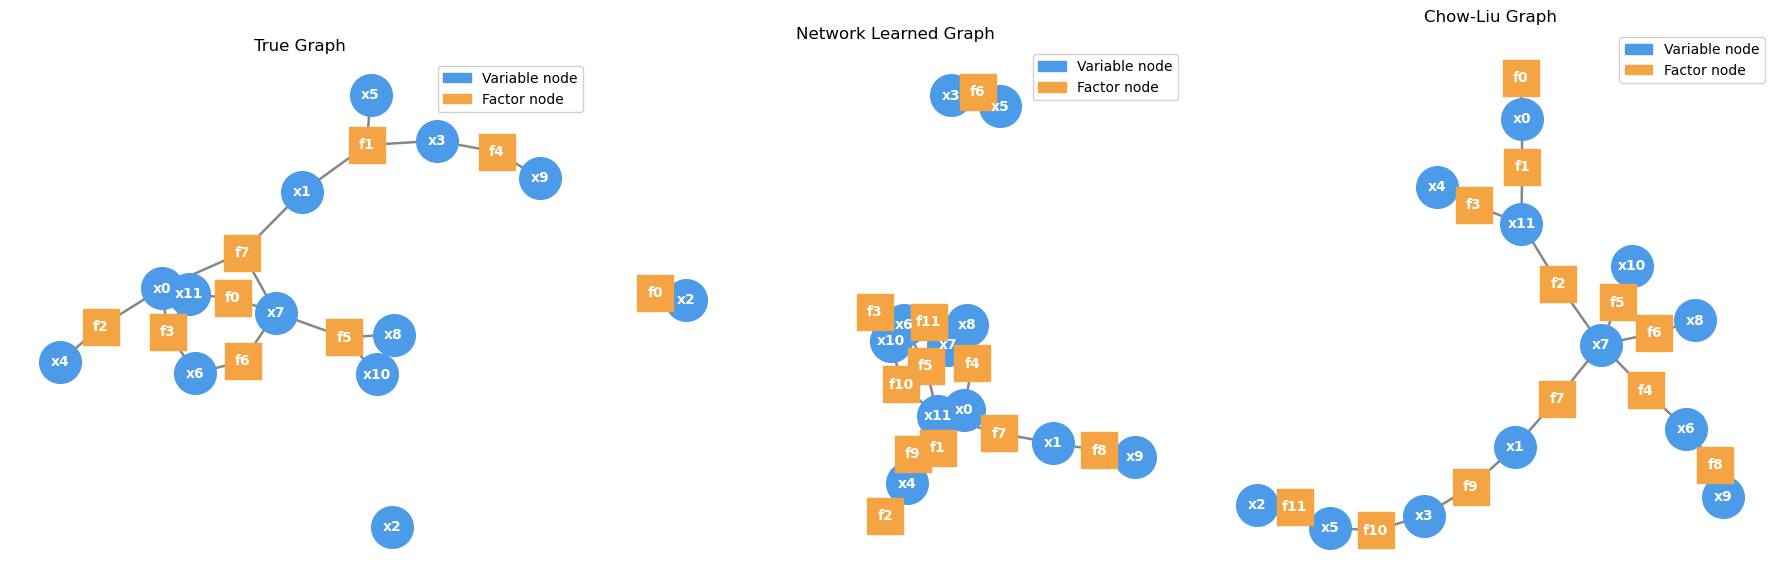

{'learners': [<learner.FactorGraphLearner at 0x14d30be90>,
 'Chow-Liu Graph': <true_graph.TrueGraph at 0x15866c790>,
 'True Graph': <true_graph.TrueGraph at 0x12d3bedd0>,
 'n_samples': 500,
 'n_variables': 12,
 'n_factors': 7,
 'KL': {'mean': 0.1680255419390247, 'sd': 0.04716835513092439},
 'KL Chow-Liu': 0.16420412202357074,
 'KL MLE': 0.763574982962337,
 'SHD': {'mean': 11.6, 'sd': 2.244994432064365},
 'SHD Chow-Liu': 10,
 'true density': 1.1818181818181819,
 'density': {'mean': 1.509090909090909, 'sd': 0.09270944570168704}}

In [38]:
show_graphs(results_graphs[4], index=0, seed_true=2, seed_lrn=2, seed_cl=9)
results_graphs[3]

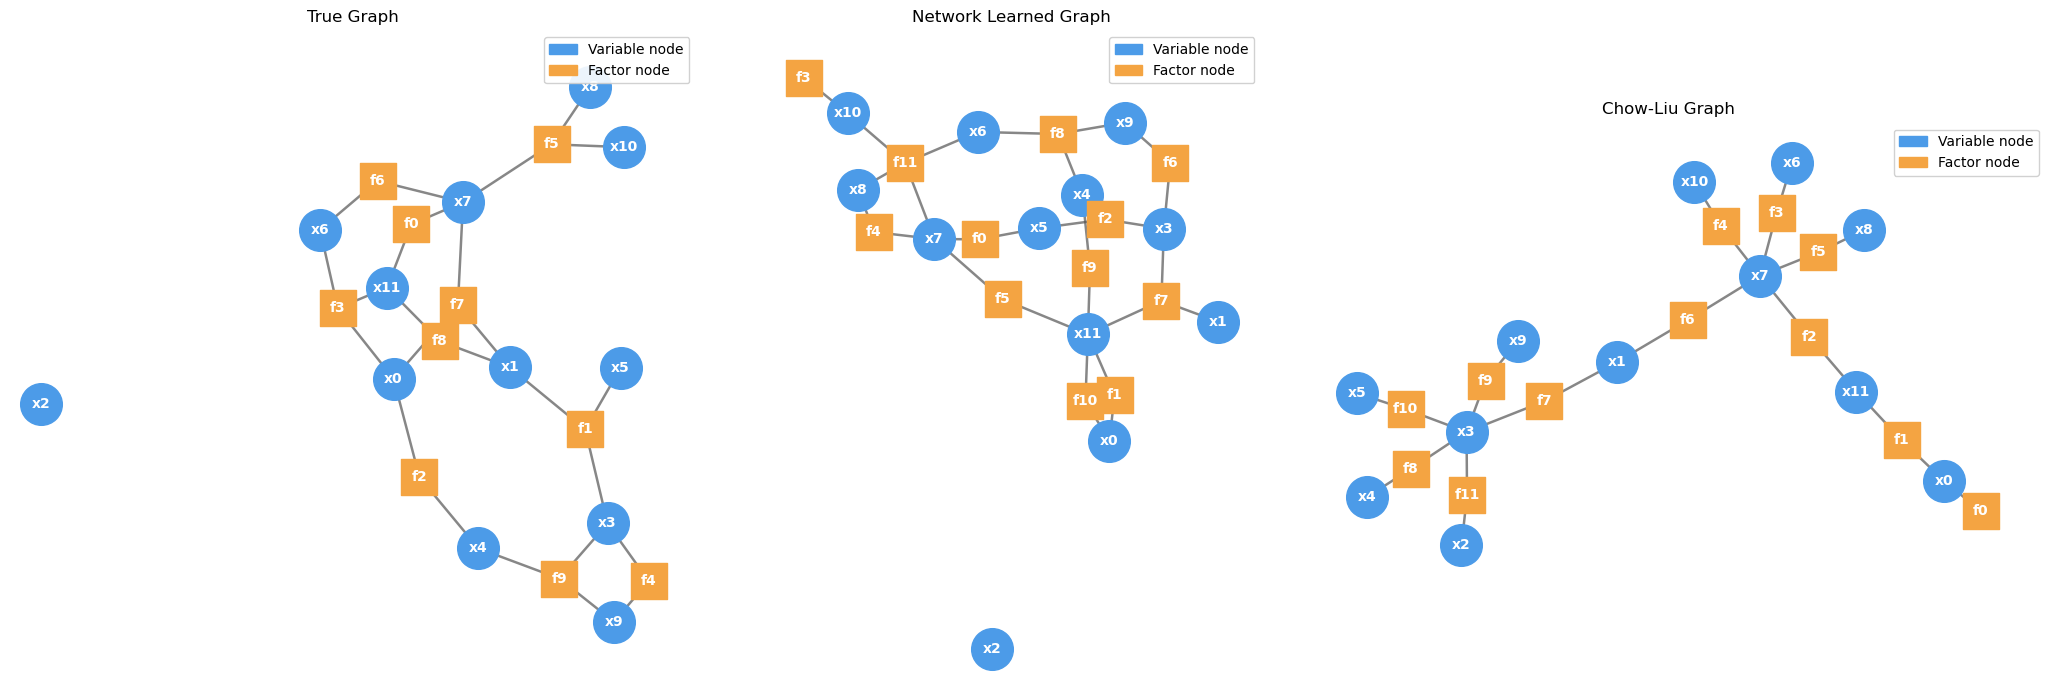

{'learners': [<learner.FactorGraphLearner at 0x1587f8cd0>,
 'Chow-Liu Graph': <true_graph.TrueGraph at 0x14cd47f90>,
 'True Graph': <true_graph.TrueGraph at 0x12d3c4510>,
 'n_samples': 500,
 'n_variables': 12,
 'n_factors': 10,
 'KL': {'mean': 0.275932266286344, 'sd': 0.04317611208162325},
 'KL Chow-Liu': 0.24592370284569645,
 'KL MLE': 0.7442771056093433,
 'SHD': {'mean': 15.0, 'sd': 2.1908902300206643},
 'SHD Chow-Liu': 10,
 'true density': 1.7272727272727273,
 'density': {'mean': 1.781818181818182, 'sd': 0.13606026860996145}}

In [39]:
show_graphs(results_graphs[6], seed_true=2, seed_lrn=16, seed_cl=6, size=7)
results_graphs[6]

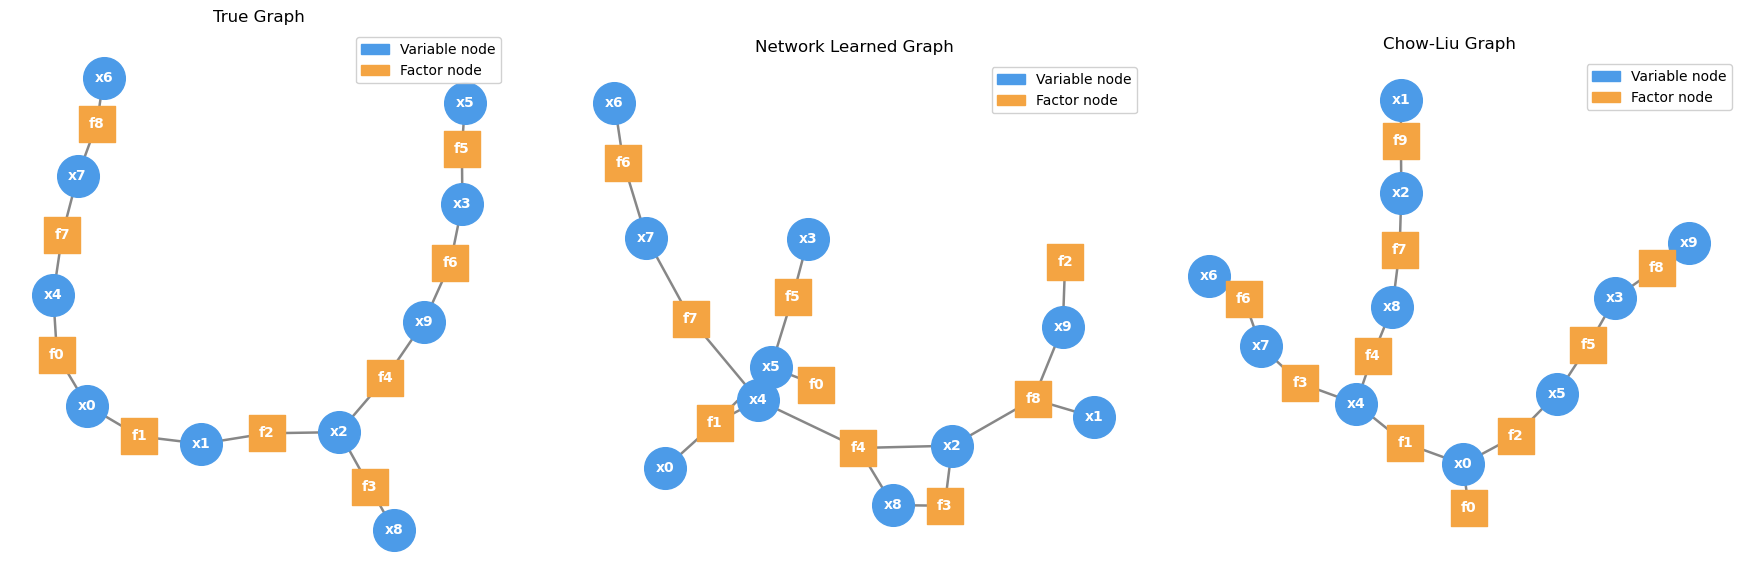

{'learners': [<learner.FactorGraphLearner at 0x148733850>,
 'Chow-Liu Graph': <true_graph.TrueGraph at 0x14c851490>,
 'True Graph': <true_graph.TrueGraph at 0x12d385b10>,
 'n_samples': 500,
 'n_variables': 10,
 'n_factors': 9,
 'KL': {'mean': 0.10156879907909726, 'sd': 0.07123867913064637},
 'KL Chow-Liu': 0.030359368393444858,
 'KL MLE': 0.4205669671009371,
 'SHD': {'mean': 12.2, 'sd': 3.7094473981982814},
 'SHD Chow-Liu': 4,
 'true density': 1.0,
 'density': {'mean': 1.5555555555555554, 'sd': 0.24343224778007386}}

In [40]:
show_graphs(results_trees[1], seed_true=2, seed_lrn=2, seed_cl=2)
results_trees[1]

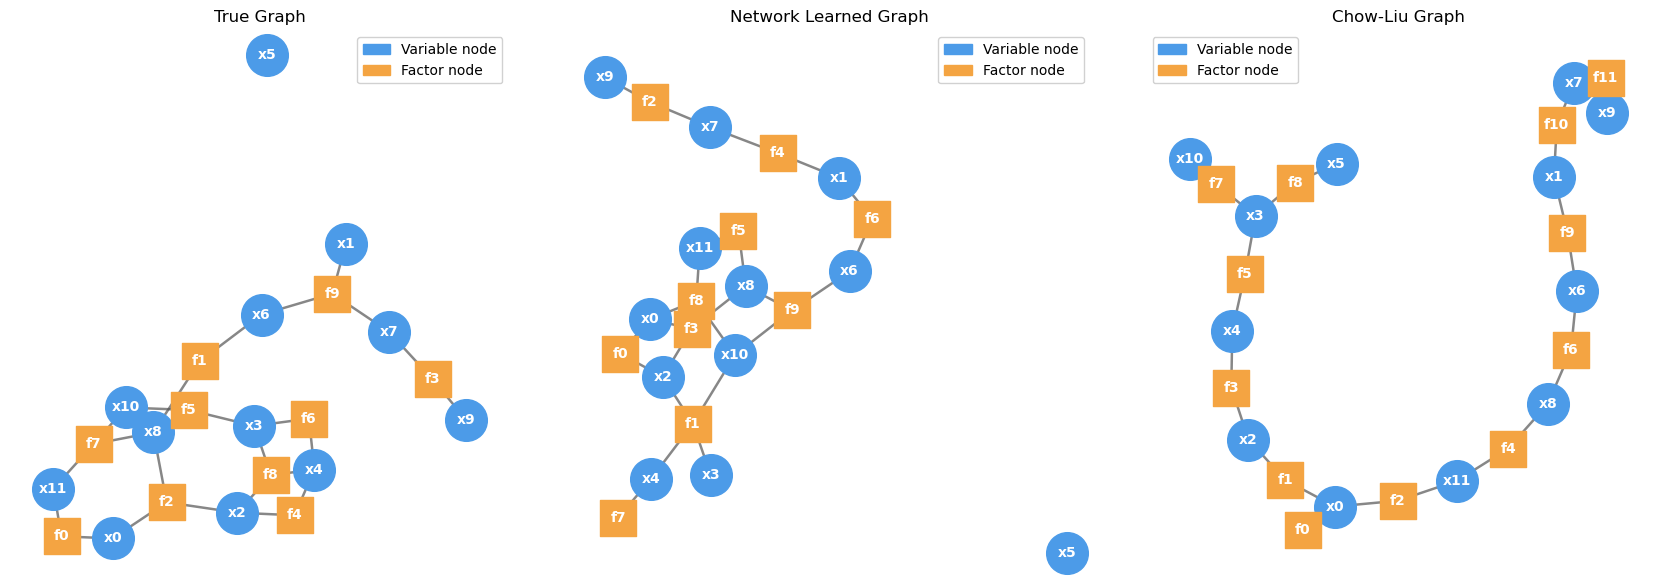

{'learners': [<learner.FactorGraphLearner at 0x15ab914d0>,
 'Chow-Liu Graph': <true_graph.TrueGraph at 0x15ad75850>,
 'True Graph': <true_graph.TrueGraph at 0x12d3bcc10>,
 'n_samples': 10000,
 'n_variables': 12,
 'n_factors': 10,
 'KL': {'mean': 0.06350962020574515, 'sd': 0.055165427093841715},
 'KL Chow-Liu': 0.10684940765093898,
 'KL MLE': 0.12331904691887144,
 'SHD': {'mean': 4.4, 'sd': 1.3564659966250536},
 'SHD Chow-Liu': 7,
 'true density': 1.4545454545454546,
 'density': {'mean': 1.4545454545454546, 'sd': 0.20730462274529782}}

In [41]:
show_graphs(results_samples[-1], seed_true=2, seed_lrn=4, seed_cl=2)
results_samples[-1]

# Final Visualizations

In [65]:
def extract_metric(results, x):
    return [r[x] for r in results]

def plot_metric(results, x, y, ax, label=None):
    xs = [r[x] for r in results]
    if isinstance(results[0][y], dict):
        ys = [r[y]['mean'] for r in results]
    else:
        ys = [r[y] for r in results]
    ax.plot(xs, ys, label=label)

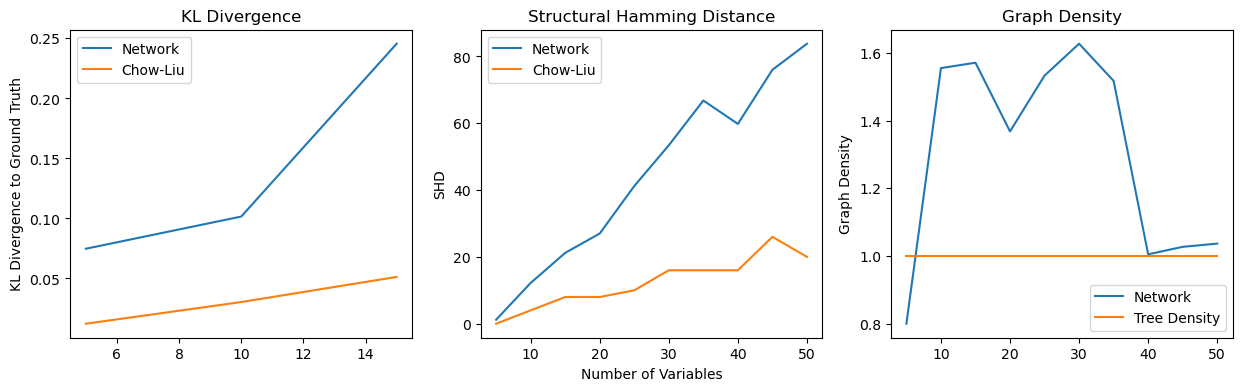

In [70]:
# Tree with varying size

fig, axs = plt.subplots(1,3,figsize=(15,4))

plot_metric(results_trees, 'n_variables', 'KL', axs[0], label="Network")
plot_metric(results_trees, 'n_variables', 'KL Chow-Liu', axs[0], label="Chow-Liu")

plot_metric(results_trees, 'n_variables', 'SHD', axs[1], label="Network")
plot_metric(results_trees, 'n_variables', 'SHD Chow-Liu', axs[1], label="Chow-Liu")

plot_metric(results_trees, 'n_variables', 'density', axs[2], label="Network")
plot_metric(results_trees, 'n_variables', 'true density', axs[2], label="Tree Density")


axs[0].set_ylabel("KL Divergence to Ground Truth")
axs[0].set_title("KL Divergence")
axs[0].legend()

axs[1].set_ylabel("SHD")
axs[1].set_xlabel("Number of Variables")
axs[1].set_title("Structural Hamming Distance")
axs[1].legend()

axs[2].set_ylabel("Graph Density")
axs[2].set_title("Graph Density")
axs[2].legend()

# plt.savefig('../img/comp_tree.png')
plt.show()


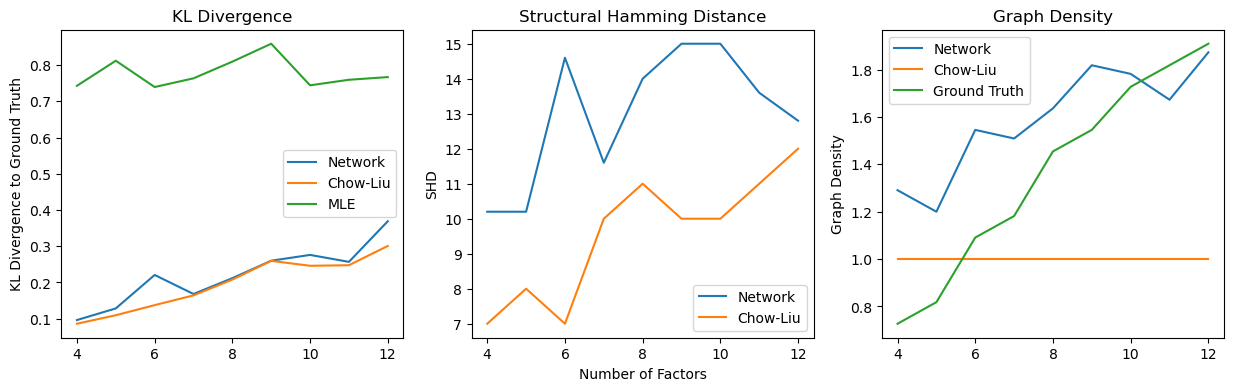

In [75]:
# Graph with varying density

fig, axs = plt.subplots(1,3,figsize=(15,4))

plot_metric(results_graphs, 'n_factors', 'KL', axs[0], label="Network")
plot_metric(results_graphs, 'n_factors', 'KL Chow-Liu', axs[0], label="Chow-Liu")
plot_metric(results_graphs, 'n_factors', 'KL MLE', axs[0], label="MLE")

plot_metric(results_graphs, 'n_factors', 'SHD', axs[1], label="Network")
plot_metric(results_graphs, 'n_factors', 'SHD Chow-Liu', axs[1], label="Chow-Liu")

plot_metric(results_graphs, 'n_factors', 'density', axs[2], label="Network")
axs[2].plot(extract_metric(results_graphs, 'n_factors'), [1 for _ in range(len(results_graphs))], label = "Chow-Liu")
plot_metric(results_graphs, 'n_factors', 'true density', axs[2], label="Ground Truth")


axs[0].set_ylabel("KL Divergence to Ground Truth")
axs[0].set_title("KL Divergence")
axs[0].legend()

axs[1].set_ylabel("SHD")
axs[1].set_xlabel("Number of Factors")
axs[1].set_title("Structural Hamming Distance")
axs[1].legend()

axs[2].set_ylabel("Graph Density")
axs[2].set_title("Graph Density")
axs[2].legend()

# plt.savefig('../img/comp_graph.png')
plt.show()

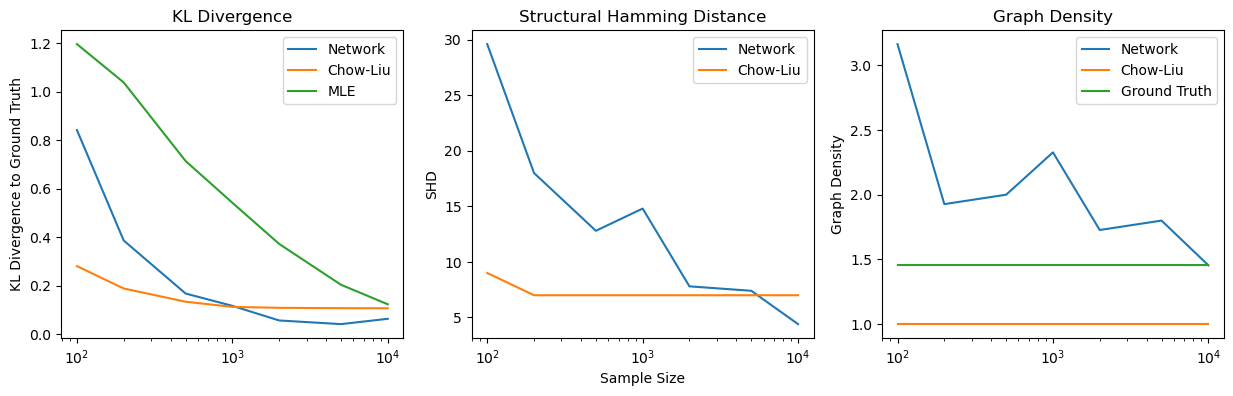

In [78]:
# Fixed graph with varying sample size

fig, axs = plt.subplots(1,3,figsize=(15,4))

plot_metric(results_samples, 'n_samples', 'KL', axs[0], label="Network")
plot_metric(results_samples, 'n_samples', 'KL Chow-Liu', axs[0], label="Chow-Liu")
plot_metric(results_samples, 'n_samples', 'KL MLE', axs[0], label="MLE")

plot_metric(results_samples, 'n_samples', 'SHD', axs[1], label="Network")
plot_metric(results_samples, 'n_samples', 'SHD Chow-Liu', axs[1], label="Chow-Liu")

plot_metric(results_samples, 'n_samples', 'density', axs[2], label="Network")
axs[2].plot(extract_metric(results_samples, 'n_samples'), [1 for _ in range(len(results_samples))], label = "Chow-Liu")
plot_metric(results_samples, 'n_samples', 'true density', axs[2], label="Ground Truth")

axs[0].set_ylabel("KL Divergence to Ground Truth")
axs[0].set_title("KL Divergence")
axs[0].set_xscale('log')
axs[0].legend()

axs[1].set_ylabel("SHD")
axs[1].set_xlabel("Sample Size")
axs[1].set_title("Structural Hamming Distance")
axs[1].set_xscale('log')
axs[1].legend()

axs[2].set_ylabel("Graph Density")
axs[2].set_title("Graph Density")
axs[2].set_xscale('log')
axs[2].legend()

# plt.savefig('../img/comp_samples.png')
plt.show()

# Viusalizations for Slides

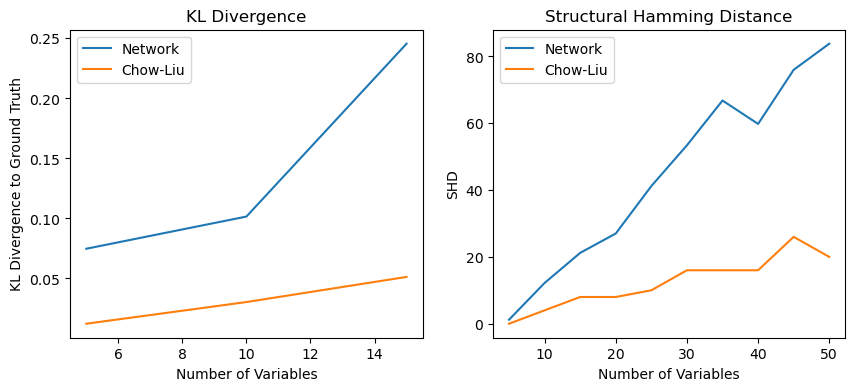

In [84]:
# Tree with varying size

fig, axs = plt.subplots(1,2,figsize=(10,4))

plot_metric(results_trees, 'n_variables', 'KL', axs[0], label="Network")
plot_metric(results_trees, 'n_variables', 'KL Chow-Liu', axs[0], label="Chow-Liu")

plot_metric(results_trees, 'n_variables', 'SHD', axs[1], label="Network")
plot_metric(results_trees, 'n_variables', 'SHD Chow-Liu', axs[1], label="Chow-Liu")


axs[0].set_ylabel("KL Divergence to Ground Truth")
axs[0].set_xlabel("Number of Variables")
axs[0].set_title("KL Divergence")
axs[0].legend()

axs[1].set_ylabel("SHD")
axs[1].set_xlabel("Number of Variables")
axs[1].set_title("Structural Hamming Distance")
axs[1].legend()

# plt.savefig('../slide_img/comp_tree.png')
plt.show()


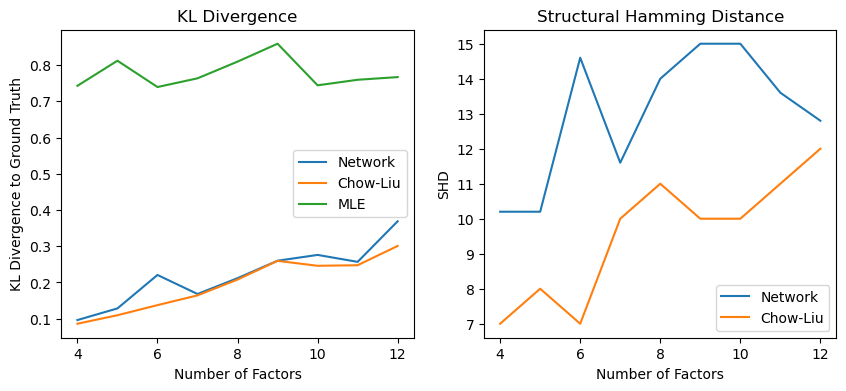

In [87]:
# Graph with varying density

fig, axs = plt.subplots(1,2,figsize=(10,4))

plot_metric(results_graphs, 'n_factors', 'KL', axs[0], label="Network")
plot_metric(results_graphs, 'n_factors', 'KL Chow-Liu', axs[0], label="Chow-Liu")
plot_metric(results_graphs, 'n_factors', 'KL MLE', axs[0], label="MLE")

plot_metric(results_graphs, 'n_factors', 'SHD', axs[1], label="Network")
plot_metric(results_graphs, 'n_factors', 'SHD Chow-Liu', axs[1], label="Chow-Liu")


axs[0].set_ylabel("KL Divergence to Ground Truth")
axs[0].set_xlabel("Number of Factors")
axs[0].set_title("KL Divergence")
axs[0].legend()

axs[1].set_ylabel("SHD")
axs[1].set_xlabel("Number of Factors")
axs[1].set_title("Structural Hamming Distance")
axs[1].legend()

# plt.savefig('../slide_img/comp_graph.png')
plt.show()

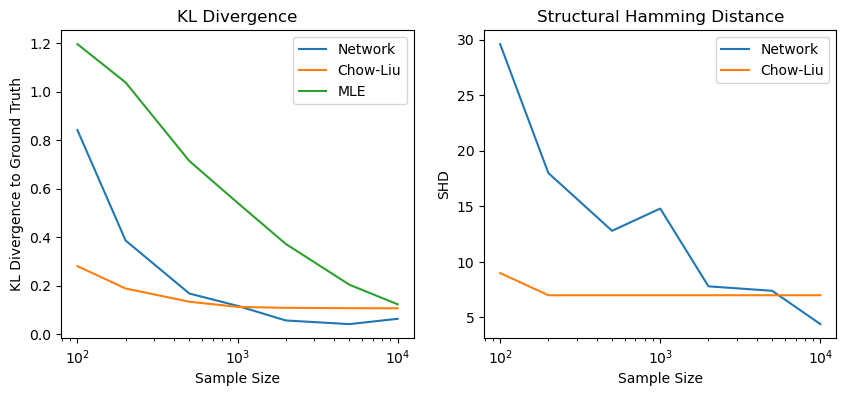

In [89]:
# Fixed graph with varying sample size

fig, axs = plt.subplots(1,2,figsize=(10,4))

plot_metric(results_samples, 'n_samples', 'KL', axs[0], label="Network")
plot_metric(results_samples, 'n_samples', 'KL Chow-Liu', axs[0], label="Chow-Liu")
plot_metric(results_samples, 'n_samples', 'KL MLE', axs[0], label="MLE")

plot_metric(results_samples, 'n_samples', 'SHD', axs[1], label="Network")
plot_metric(results_samples, 'n_samples', 'SHD Chow-Liu', axs[1], label="Chow-Liu")

axs[0].set_ylabel("KL Divergence to Ground Truth")
axs[0].set_xlabel("Sample Size")
axs[0].set_title("KL Divergence")
axs[0].set_xscale('log')
axs[0].legend()

axs[1].set_ylabel("SHD")
axs[1].set_xlabel("Sample Size")
axs[1].set_title("Structural Hamming Distance")
axs[1].set_xscale('log')
axs[1].legend()

# plt.savefig('../slide_img/comp_samples.png')
plt.show()

# Show Graphs

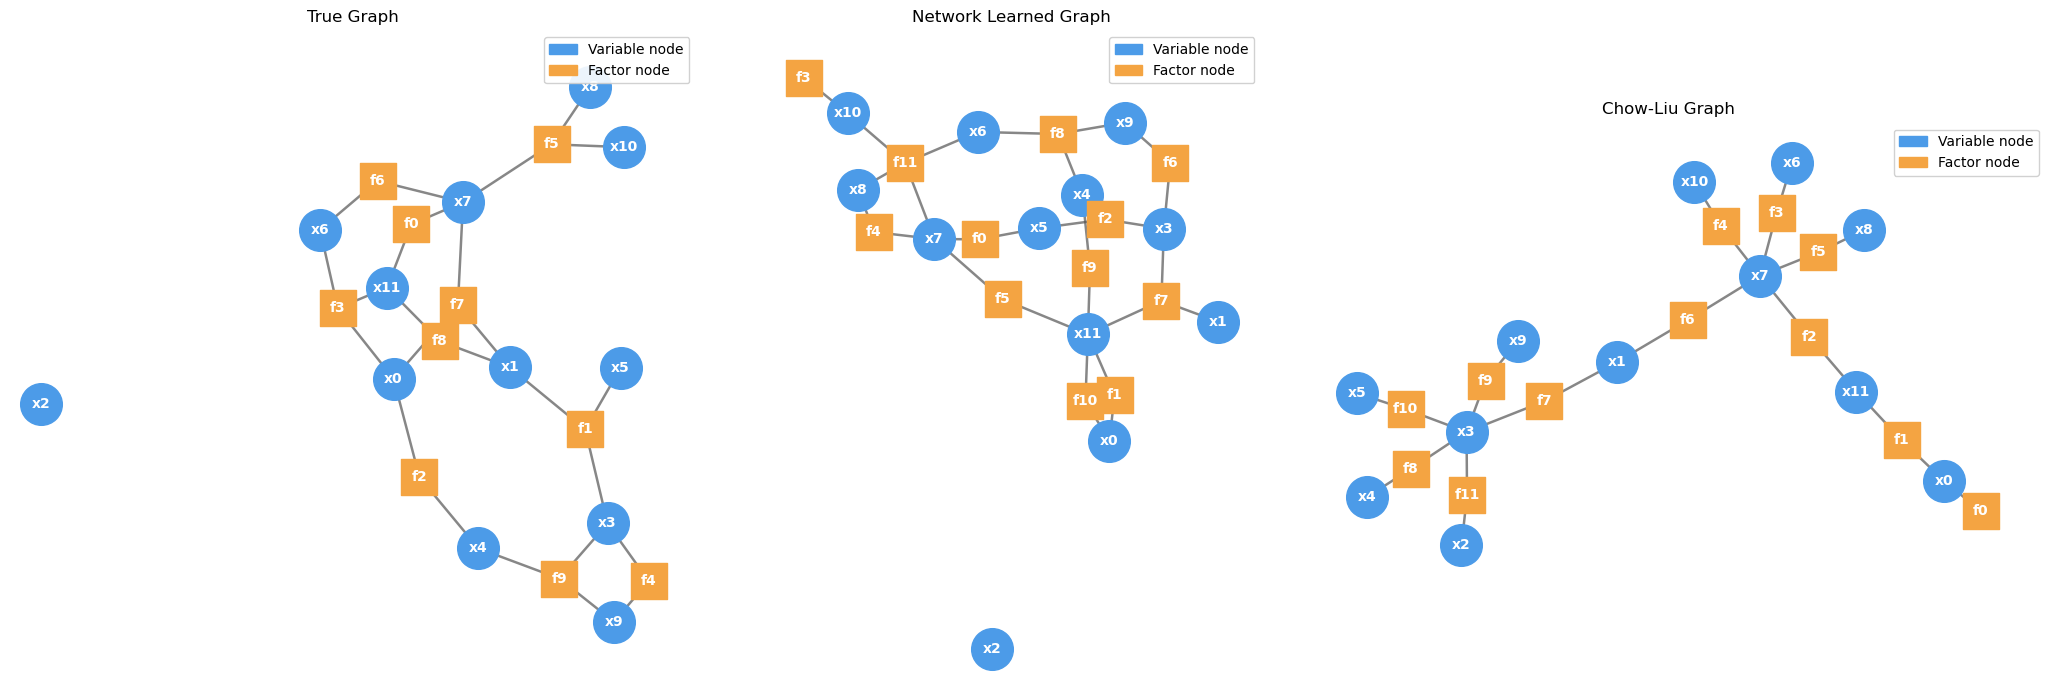

In [100]:
EXAMPLE = 6
res = results_graphs[EXAMPLE]

# show_graphs(results_graphs[6], seed_true=2, seed_lrn=16, seed_cl=6, size=7, savefig=True, path="../img/comp_ex.png")
show_graphs(res, seed_true=2, seed_lrn=16, seed_cl=6, size=7)

In [93]:
compare_graph(res['True Graph'], res['learners'][0])

=== GRAPH 1 FACTORS ===
[7, 11]
[1, 3, 5]
[0, 4]
[0, 6, 11]
[3, 9]
[7, 8, 10]
[6, 7]
[0, 1, 7]
[1, 11]
[3, 4, 9]

=== GRAPH 2 FACTORS ===
[5, 7]
[0, 11]
[3, 4, 5]
[10]
[7, 8]
[7, 11]
[3, 9]
[1, 3, 11]
[4, 6, 9]
[4, 11]
[0, 11]
[6, 7, 8, 10]


In [94]:
compare_graph(res['True Graph'], res['Chow-Liu Graph'])

=== GRAPH 1 FACTORS ===
[7, 11]
[1, 3, 5]
[0, 4]
[0, 6, 11]
[3, 9]
[7, 8, 10]
[6, 7]
[0, 1, 7]
[1, 11]
[3, 4, 9]

=== GRAPH 2 FACTORS ===
[0]
[0, 11]
[7, 11]
[6, 7]
[7, 10]
[7, 8]
[1, 7]
[1, 3]
[3, 4]
[3, 9]
[3, 5]
[2, 3]


In [95]:
factor_metrics(res['True Graph'], res['learners'][0])

{'precision': 0.18181818165289254,
 'recall': 0.1999999998,
 'tp': 2,
 'fp': 9,
 'fn': 8}

In [96]:
factor_metrics(res['True Graph'], res['Chow-Liu Graph'])

{'precision': 0.24999999979166665,
 'recall': 0.29999999969999996,
 'tp': 3,
 'fp': 9,
 'fn': 7}

In [97]:
edge_metrics(res['True Graph'], res['learners'][0])

{'precision': 0.5999999997,
 'recall': 0.631578947036011,
 'tp': 12,
 'fp': 8,
 'fn': 7}

In [98]:
edge_metrics(res['True Graph'], res['Chow-Liu Graph'])

{'precision': 0.9090909082644627,
 'recall': 0.5263157891966759,
 'tp': 10,
 'fp': 1,
 'fn': 9}